# Mushroom Classification: Poisonous or Edible?
#### Deep Learning based Classificaiton Project

###### Objective: Classify mushrooms as edible or poisonous based on their physical and environmental features.
###### Goal: Identify key features through EDA and train an ANN model to make predictions.

In [1]:
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import torch
import pandas as pd

### Loading the data

In [2]:
df = pd.read_csv("mushrooms.csv")

In [3]:
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

In [5]:
df.describe()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,...,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,2,6,4,10,2,9,2,2,2,12,...,4,9,9,1,4,3,5,9,6,7
top,e,x,y,n,f,n,f,c,b,b,...,s,w,w,p,w,o,p,w,v,d
freq,4208,3656,3244,2284,4748,3528,7914,6812,5612,1728,...,4936,4464,4384,8124,7924,7488,3968,2388,4040,3148


In [6]:
df["class"].unique()

array(['p', 'e'], dtype=object)

In [7]:
df.columns

Index(['class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor',
       'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color',
       'stalk-shape', 'stalk-root', 'stalk-surface-above-ring',
       'stalk-surface-below-ring', 'stalk-color-above-ring',
       'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number',
       'ring-type', 'spore-print-color', 'population', 'habitat'],
      dtype='object')

## EDA

### Target Variable Balance

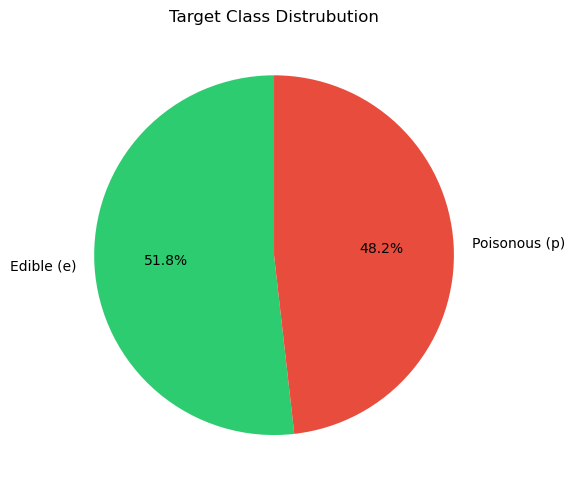

In [8]:
colors = ["#2ecc71", "#e74c3c"] # green for edible, red for poisonous

plt.figure(figsize = (7, 5))
class_counts = df["class"].value_counts()
plt.pie( class_counts, labels = ["Edible (e)", "Poisonous (p)"], autopct="%1.1f%%", startangle=90, colors=colors)
plt.title("Target Class Distrubution")
plt.tight_layout()
plt.show()

Dataset is balanced.

### Key Features vs Edibility

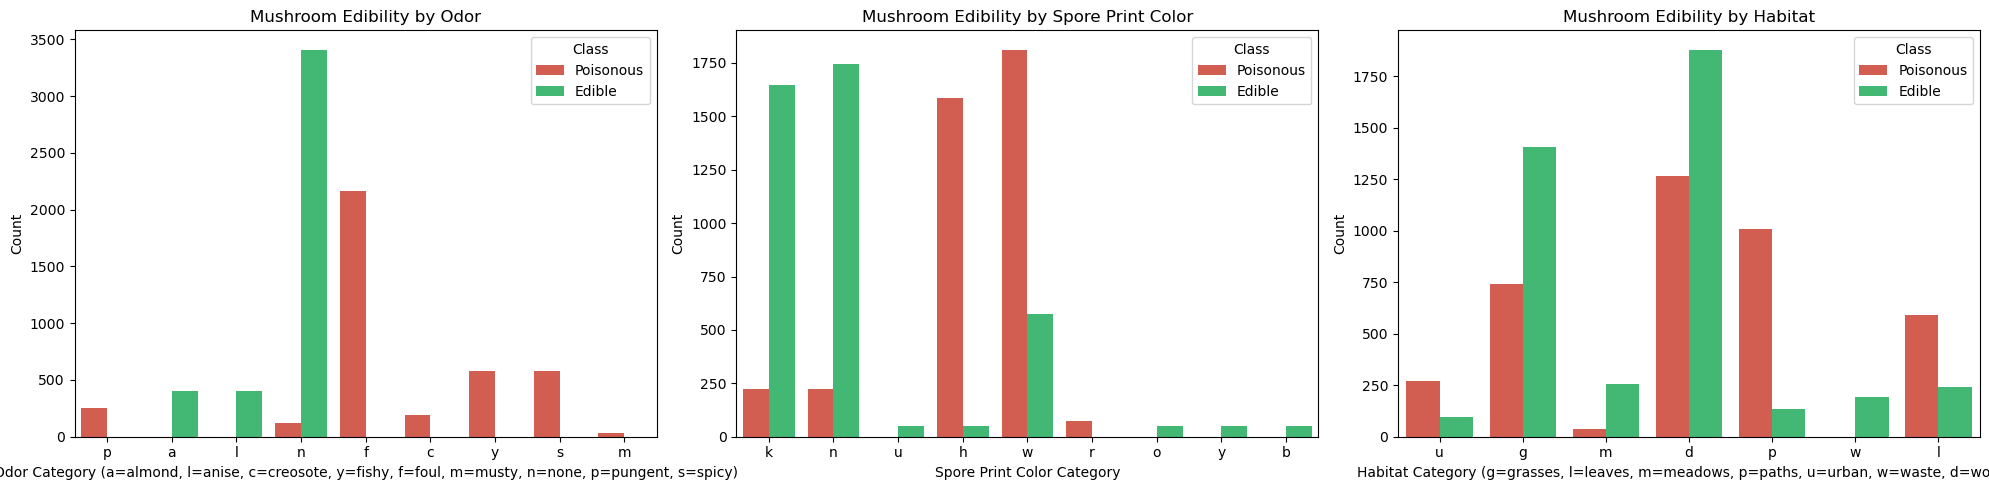

In [9]:
fig, axes = plt.subplots(1,3, figsize = (20,5))
palette = {"e": "#2ecc71", "p": "#e74c3c"} # green for edible, red for poisonous

# chart 1: odor (smell) vs class
sns.countplot(data = df, x = "odor", hue = "class", palette = palette, ax = axes[0])
axes[0].set_title("Mushroom Edibility by Odor")
axes[0].set_xlabel("Odor Category (a=almond, l=anise, c=creosote, y=fishy, f=foul, m=musty, n=none, p=pungent, s=spicy)")
axes[0].set_ylabel("Count")
axes[0].legend(title = "Class", labels = ["Poisonous", "Edible"])

# chart 2: spore print color vs class
sns.countplot(data = df, x = "spore-print-color", hue = "class", palette = palette, ax = axes[1])
axes[1].set_title("Mushroom Edibility by Spore Print Color")
axes[1].set_xlabel("Spore Print Color Category")
axes[1].set_ylabel("Count")
axes[1].legend(title = "Class", labels = ["Poisonous", "Edible"])

# chart 3: habitat vs class
sns.countplot(data = df, x = "habitat", hue = "class", palette = palette, ax = axes[2])
axes[2].set_title("Mushroom Edibility by Habitat")
axes[2].set_xlabel("Habitat Category (g=grasses, l=leaves, m=meadows, p=paths, u=urban, w=waste, d=woods)")
axes[2].set_ylabel("Count")
axes[2].legend(title = "Class", labels = ["Poisonous", "Edible"])

plt.tight_layout()
plt.show()

Odor is the strongest predictor, specific spore print colors are also strong indicators.

### Cramer's V Heatmap

In [10]:
# defining cramer's v func
from scipy.stats import chi2_contingency

def cramers_v(x,y):
    confusion_matrix = pd.crosstab(x,y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()

    if n == 0:
        return 0.0

    phi2 = chi2 / n
    r,k = confusion_matrix.shape

    # bias correlation

    phi2_corr = max(0, phi2 - ((k-1) * (r-1)) / (n-1))
    r_corr = r - ((r-1) **2) / (n-1)
    k_corr = k - ((k-1) **2) / (n-1)

    denom = min((k_corr - 1), (r_corr - 1))
    if denom <= 0:
        return 0.0
    return np.sqrt(phi2_corr / denom)

In [11]:
# creating the cramer's v matrix between all features
cols = df.columns
cramer_matrix = pd.DataFrame(index = cols, columns = cols, dtype = float)

for c1 in cols:
    for c2 in cols:
        if c1 == c2:
            cramer_matrix.loc[c1,c2] = 1.0
        else:
            cramer_matrix.loc[c1,c2] = cramers_v(df[c1], df[c2])

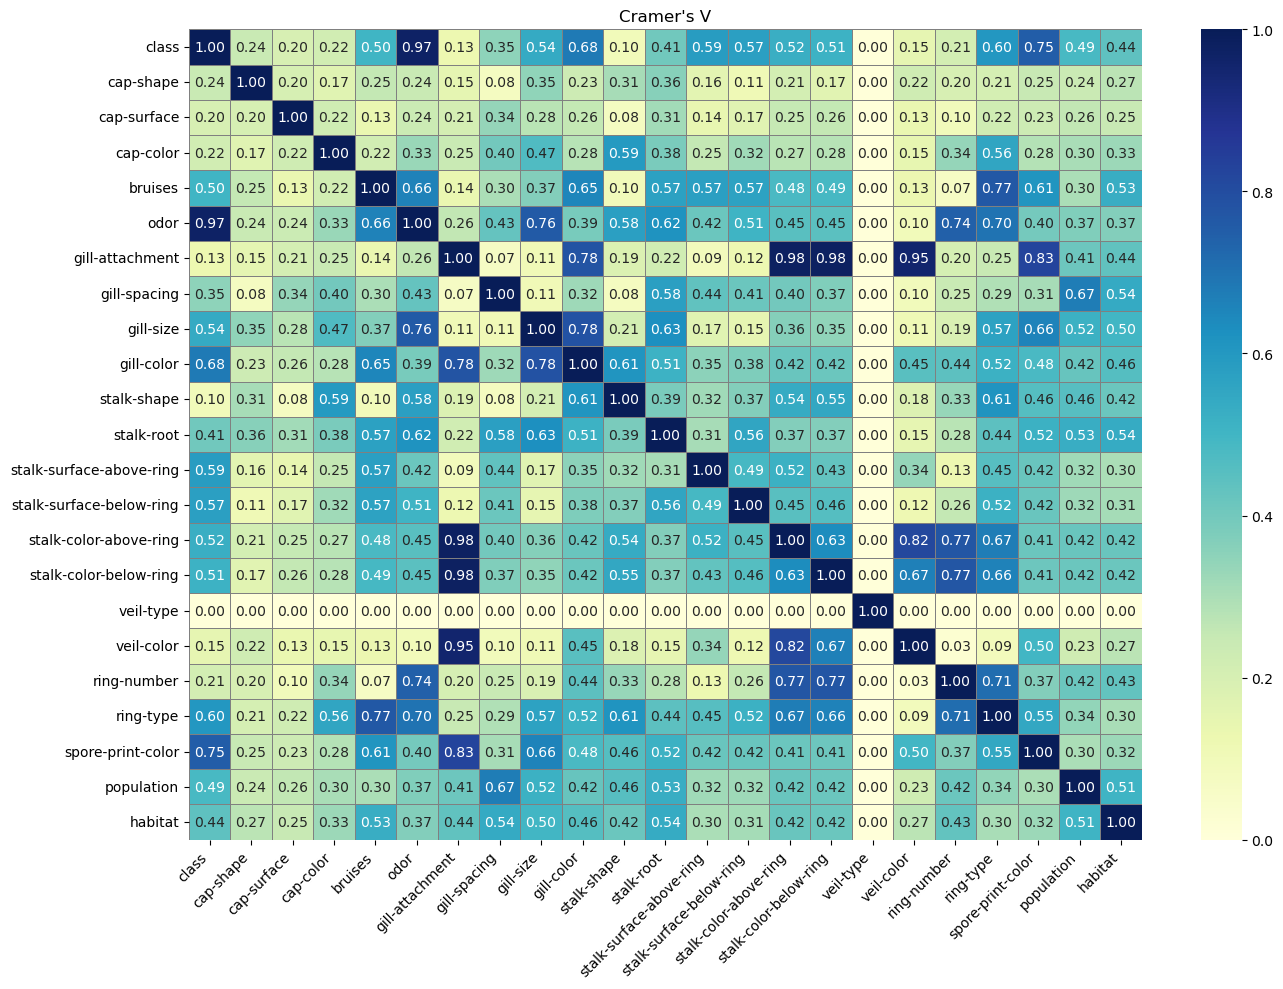

In [12]:
# heatmap visualization
plt.figure(figsize = (14,10))
sns.heatmap(cramer_matrix, annot = True, fmt = ".2f", cmap="YlGnBu", cbar = True, linewidths=0.5, linecolor = "gray")
plt.title("Cramer's V")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

#### Key insights from Cramer's V Matrix

##### veil-type
- Cramer's V matrix shows us *veil-type* is clearly an irrelevant feature and it will be dropped during preprocessing.

##### odor, spore-print-color, gill-color
- *odor*, *spore-print-color*, *gill-color* are key predictors with high feature importance.

##### gill-attachment
- *gill-attachment* feature shows high multicollinearity and can be safely removed during data preparition.

## Data Preprocessing and Feature Engineering

In [13]:
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

In [14]:
# let's drop the irrelevant veil-type columns and gill-attachment column which shows multicollinearity
df_clean = df.drop(columns = ["veil-type", "gill-attachment"])

In [15]:
# let's get the feature variables and target variable and convert target variable to binary encoding 
X = df_clean.drop(columns = ["class"])
y = df_clean["class"].map({"e":0, "p":1})

In [16]:
# converting categorical features with one-hot-encoding
X_encoded = pd.get_dummies(X, drop_first = True, dtype = float)

print(f"Feature Count after One-Hot Encoding: {X_encoded.shape[1]}")

Feature Count after One-Hot Encoding: 94


In [17]:
# train-test split
X_train, X_test, y_train, y_test = train_test_split(X_encoded.values, y.values, test_size=0.2, random_state=42, stratify = y.values)

In [18]:
# converting numpy arrays to pytorch tensors
X_train_tensor = torch.tensor(X_train, dtype = torch.float32)
y_train_tensor = torch.tensor(y_train, dtype = torch.float32).unsqueeze(1)

X_test_tensor = torch.tensor(X_test, dtype = torch.float32)
y_test_tensor = torch.tensor(y_test, dtype = torch.float32).unsqueeze(1)

In [19]:
# creating pytorch dataloader
BATCH_SIZE = 64

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size = BATCH_SIZE, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = BATCH_SIZE, shuffle = False)


## Artificial Neural Network Architecture

In [20]:
from torch import nn
from torch import optim

# custom torch nn class
class MushroomANN(nn.Module):
    def __init__(self,input_features):
        super().__init__()
        self.linear_model_stack = nn.Sequential(
            nn.Linear(input_features, 64),
            nn.ReLU(),
            nn.Linear(64,64),
            nn.ReLU(),
            nn.Linear(64,1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.linear_model_stack(x)

In [21]:
# creating the model
INPUT_FEATURES = X_train_tensor.shape[1]
model = MushroomANN(input_features=INPUT_FEATURES)

# loss function
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr = 0.001)

print(model)

MushroomANN(
  (linear_model_stack): Sequential(
    (0): Linear(in_features=94, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=1, bias=True)
    (5): Sigmoid()
  )
)


## Model Training and Evaluation

In [25]:
def calculate_acc(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

In [27]:
# defining the epoch count
EPOCHS = 100

train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []

for epoch in range(EPOCHS):
    # training
    model.train()
    
    running_train_loss = 0.0
    running_train_acc = 0.0
    
    for batch_X, batch_y in train_loader:
        train_logits = model(batch_X)
        
        loss = criterion(train_logits, batch_y)
        
        train_pred = (train_logits >= 0.5).float()
        acc = calculate_acc(batch_y, train_pred)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item() * batch_X.size(0)
        running_train_acc += acc * batch_X.size(0)
        
    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    epoch_train_acc = running_train_acc / len(train_loader.dataset)
    
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)

    # evaluation
    model.eval()
    
    with torch.inference_mode():
        test_logits = model(X_test_tensor)
        test_loss = criterion(test_logits, y_test_tensor)
        
        test_pred = (test_logits >= 0.5).float()
        test_acc = calculate_acc(y_test_tensor, test_pred)
        
    test_losses.append(test_loss.item())
    test_accuracies.append(test_acc)
    
    if epoch % 10 == 0:
        print(f"Epoch: {epoch:3d} | Train Loss: {epoch_train_loss:.4f} | Train Acc: %{epoch_train_acc:.2f} | Test Loss: {test_loss.item():.4f} | Test Acc: %{test_acc:.2f}")

Epoch:   0 | Train Loss: 0.0000 | Train Acc: %100.00 | Test Loss: 0.0000 | Test Acc: %100.00
Epoch:  10 | Train Loss: 0.0000 | Train Acc: %100.00 | Test Loss: 0.0000 | Test Acc: %100.00
Epoch:  20 | Train Loss: 0.0000 | Train Acc: %100.00 | Test Loss: 0.0000 | Test Acc: %100.00
Epoch:  30 | Train Loss: 0.0000 | Train Acc: %100.00 | Test Loss: 0.0000 | Test Acc: %100.00
Epoch:  40 | Train Loss: 0.0000 | Train Acc: %100.00 | Test Loss: 0.0000 | Test Acc: %100.00
Epoch:  50 | Train Loss: 0.0000 | Train Acc: %100.00 | Test Loss: 0.0000 | Test Acc: %100.00
Epoch:  60 | Train Loss: 0.0000 | Train Acc: %100.00 | Test Loss: 0.0000 | Test Acc: %100.00
Epoch:  70 | Train Loss: 0.0000 | Train Acc: %100.00 | Test Loss: 0.0000 | Test Acc: %100.00
Epoch:  80 | Train Loss: 0.0000 | Train Acc: %100.00 | Test Loss: 0.0000 | Test Acc: %100.00
Epoch:  90 | Train Loss: 0.0000 | Train Acc: %100.00 | Test Loss: 0.0000 | Test Acc: %100.00


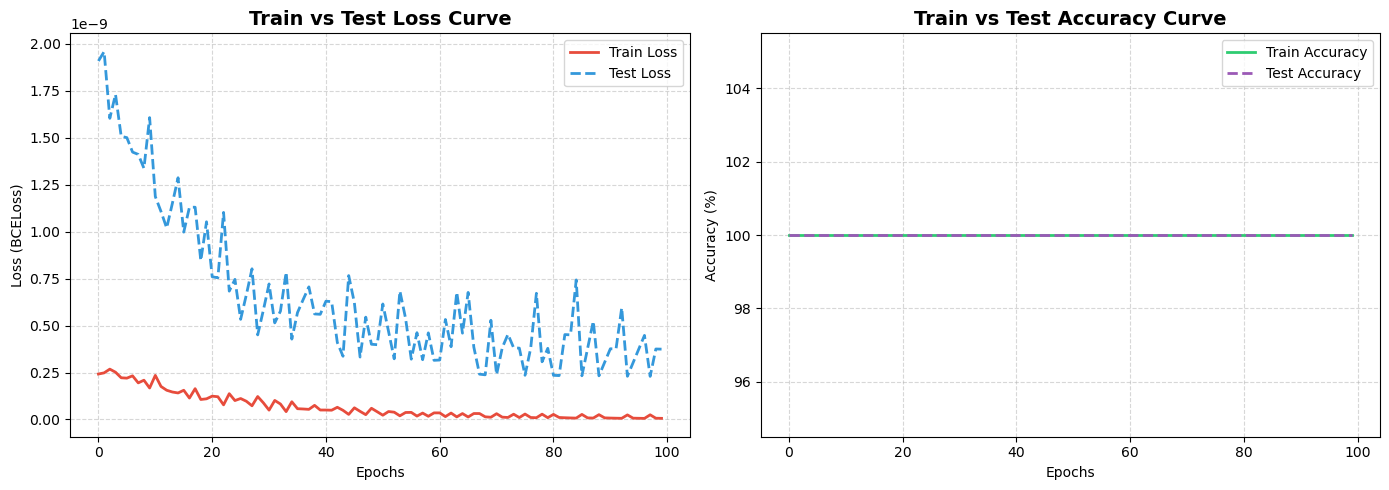

In [28]:
# visualization the process

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss", color="#e74c3c", linewidth=2)
plt.plot(test_losses, label="Test Loss", color="#3498db", linewidth=2, linestyle="--")
plt.title("Train vs Test Loss Curve", fontsize=14, fontweight="bold")
plt.xlabel("Epochs")
plt.ylabel("Loss (BCELoss)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label="Train Accuracy", color="#2ecc71", linewidth=2)
plt.plot(test_accuracies, label="Test Accuracy", color="#9b59b6", linewidth=2, linestyle="--")
plt.title("Train vs Test Accuracy Curve", fontsize=14, fontweight="bold")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()


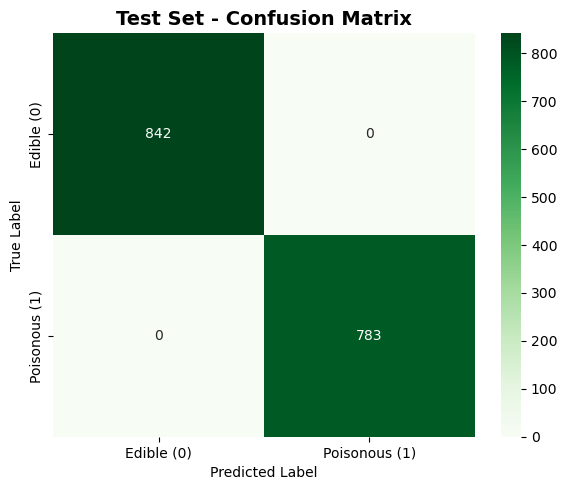

In [32]:
# confusion matrix

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_true = y_test_tensor.numpy()
y_pred = test_pred.numpy()

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Edible (0)', 'Poisonous (1)'], 
            yticklabels=['Edible (0)', 'Poisonous (1)'])
plt.title('Test Set - Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()
